# EDA

Notebook destinado a descoberta e exploração inicial do dataset visando entender como preparar ele para a modelagem


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml

pd.set_option("display.max_columns", None)

In [2]:
NUMERICAL_VARIABLES = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
]

COUNT_VARIABLES = [
    "Administrative",
    "Informational",
    "ProductRelated",
]

CATEGORICAL_VARIABLES = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend",
    "Revenue",
]

## Leitura da base

In [3]:
PROJECT_ROOT = Path("./").resolve().parent

config_path = PROJECT_ROOT / "configs" / "config.yaml"
with config_path.open(encoding="utf-8") as config_file:
    config = yaml.safe_load(config_file)

RAW_DATASET_PATH = (
    PROJECT_ROOT / config["data"]["raw_path"] / config["data"]["dataset_file"]
)

In [4]:
df = pd.read_csv(RAW_DATASET_PATH)
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## Visão geral

In [5]:
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

df.info()

Linhas: 12330
Colunas: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 

In [6]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique": df.nunique(),
    "duplicate_values": df.duplicated().sum(),
})

summary

,dtype,missing,missing_pct,unique,duplicate_values
Administrative,int64,0,0.0,27,125
Administrative_Duration,float64,0,0.0,3335,125
Informational,int64,0,0.0,17,125
Informational_Duration,float64,0,0.0,1258,125
ProductRelated,int64,0,0.0,311,125
ProductRelated_Duration,float64,0,0.0,9551,125
BounceRates,float64,0,0.0,1872,125
ExitRates,float64,0,0.0,4777,125
PageValues,float64,0,0.0,2704,125
SpecialDay,float64,0,0.0,6,125


## Valores nulos

In [7]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = 100 * missing["missing_count"] / len(df)

missing.sort_values("missing_count", ascending=False)

,missing_count,missing_pct
Administrative,0,0.0
Administrative_Duration,0,0.0
Informational,0,0.0
Informational_Duration,0,0.0
ProductRelated,0,0.0
ProductRelated_Duration,0,0.0
BounceRates,0,0.0
ExitRates,0,0.0
PageValues,0,0.0
SpecialDay,0,0.0


## Valores duplicados

In [8]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", f"{duplicate_count / len(df) * 100:.2f}%")

Duplicate rows: 125
Duplicate percentage: 1.01%


In [9]:
if duplicate_count > 0:
    display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()).head(10))

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8247,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
10751,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
11658,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
8882,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11934,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11110,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
12159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
10341,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11801,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11938,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False


## Consistência das variáveis categóricas

In [10]:
for col in CATEGORICAL_VARIABLES:
    print(f"\n### {col}")
    print(df[col].value_counts(dropna=False))


### Month
Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

### OperatingSystems
OperatingSystems
2    6601
1    2585
3    2555
4     478
8      79
6      19
7       7
5       6
Name: count, dtype: int64

### Browser
Browser
2     7961
1     2462
4      736
5      467
6      174
10     163
8      135
3      105
13      61
7       49
12      10
11       6
9        1
Name: count, dtype: int64

### Region
Region
1    4780
3    2403
4    1182
2    1136
6     805
7     761
9     511
8     434
5     318
Name: count, dtype: int64

### TrafficType
TrafficType
2     3913
1     2451
3     2052
4     1069
13     738
10     450
6      444
8      343
5      260
11     247
20     198
9       42
7       40
15      38
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64

### VisitorType
VisitorType
Returning_Visitor    10551
New_Visitor           1694

In [11]:
expected_months = {
    "Jan", "Feb", "Mar", "Apr", "May", "June",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
}

actual_months = set(df["Month"].dropna().unique())

print("Unexpected months:", actual_months - expected_months)
print("Missing expected months:", expected_months - actual_months)

Unexpected months: set()
Missing expected months: {'Jan', 'Apr'}


In [12]:
for col in ["Month", "VisitorType"]:
    values = df[col].dropna().astype(str)

    print(f"\n### {col}")
    print("Values with leading/trailing whitespace:")
    print(values[values != values.str.strip()].unique())

    print("\nNormalized values:")
    print(values.str.strip().str.lower().value_counts())


### Month
Values with leading/trailing whitespace:
[]

Normalized values:
Month
may     3364
nov     2998
mar     1907
dec     1727
oct      549
sep      448
aug      433
jul      432
june     288
feb      184
Name: count, dtype: int64

### VisitorType
Values with leading/trailing whitespace:
[]

Normalized values:
VisitorType
returning_visitor    10551
new_visitor           1694
other                   85
Name: count, dtype: int64


## Consistência das variáveis numéricas

In [13]:
rate_cols = ["BounceRates", "ExitRates"]

for col in rate_cols:
    print(
        col,
        "min =", df[col].min(),
        "max =", df[col].max(),
        "invalid =", ((df[col] < 0) | (df[col] > 1)).sum(),
    )

BounceRates min = 0.0 max = 0.2 invalid = 0
ExitRates min = 0.0 max = 0.2 invalid = 0


In [14]:
print(
    "SpecialDay invalid:",
    ((df["SpecialDay"] < 0) | (df["SpecialDay"] > 1)).sum(),
)

SpecialDay invalid: 0


In [15]:
duration_cols = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
]

for col in duration_cols:
    invalid = (df[col] < 0).sum()
    print(f"{col}: {invalid} negative values")

Administrative_Duration: 0 negative values
Informational_Duration: 0 negative values
ProductRelated_Duration: 0 negative values


In [16]:
print("Negative PageValues:", (df["PageValues"] < 0).sum())

Negative PageValues: 0


## Consistência das variáveis inteiras

In [17]:
for col in COUNT_VARIABLES:
    print(f"\n{'=' * 50}")
    print(col)
    print(f"{df[col].nunique()} unique values")
    print(df[col].unique())


Administrative
27 unique values
[ 0  1  2  4 12  3 10  6  5  9  8 16 13 11  7 18 14 17 19 15 24 22 21 20
 23 27 26]

Informational
17 unique values
[ 0  1  2  4 16  5  3 14  6 12  7  9 10  8 11 24 13]

ProductRelated
311 unique values
[  1   2  10  19   0   3  16   7   6  23  13  20   8   5  32   4  45  14
  52   9  46  15  22  11  12  36  42  27  90  18  38  17 128  25  30  21
  51  26  28  31  24  50  96  49  68  98  67  55  35  37  29  34  71  63
  87  40  33  54  64  75  39 111  81  61  47  44  88 149  41  79  66  43
 258  80  62  83 173  48  58  57  56  69  82  59 109 287  53  84  78 137
 113  89  65  60 104 129  77  74  93  76  72 194 140 110 132 115  73 328
 160  86 150  95 130 151 117 124 127 125 116 105  92 157 154 220 187 112
 131 159  94 204 142 206 102 313 145  85  97 198 181 126 106 101 108 119
  70 122  91 276 100 291 114 172 217 141 133 156 136 180 135 195  99 362
 179 118 175 148 440 103 178 184 705 134 176 146 189 120 193 222 121 107
 305 199 439 223 230 280 377 310 1

## Variáveis de baxíssima cardinalidade

In [18]:
nunique = df.nunique().sort_values()
nunique.to_frame("unique_values")

,unique_values
Revenue,2
Weekend,2
VisitorType,3
SpecialDay,6
OperatingSystems,8
Region,9
Month,10
Browser,13
Informational,17
TrafficType,20


In [19]:
PERCENTUAL_LIMIT = 95
low_variance_cols = []

for col in df.columns:
    most_common_pct = df[col].value_counts(normalize=True, dropna=False).iloc[0] * 100

    if most_common_pct >= PERCENTUAL_LIMIT:
        low_variance_cols.append((col, most_common_pct))

pd.DataFrame(
    low_variance_cols,
    columns=["column", "most_common_value_pct"],
)

,column,most_common_value_pct


## Balanceamento da target

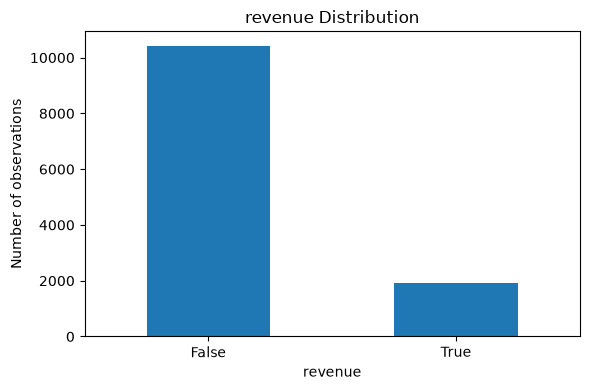

In [20]:

target_col = config["model"]["target_column"]

df.columns = df.columns.str.lower()
df.columns

target_distribution = (
    df[target_col]
    .value_counts(dropna=False)
    .sort_index()
)

ax = target_distribution.plot(
    kind="bar",
    figsize=(6, 4),
)

ax.set_title(f"{target_col} Distribution")
ax.set_xlabel(target_col)
ax.set_ylabel("Number of observations")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
target_distribution = (
    df[target_col]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame("count")
)

target_distribution["percentage"] = (
    target_distribution["count"] / len(df) * 100
)

target_distribution

,count,percentage
revenue,,
False,10422,84.525547
True,1908,15.474453
